## RNN from scratch using Tensorflow.

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.utils import to_categorical 

# 1. Load and clean the data
data = """
The quick brown fox jumps over the lazy dog.
The fast brown wolf leaps over the sleepy cat.
The quick red fox jumps high.
"""

corpus = data.lower().split("\n")
corpus = [line for line in corpus if line]

print(f'Raw Corpus: \n{corpus}')

Raw Corpus: 
['the quick brown fox jumps over the lazy dog.', 'the fast brown wolf leaps over the sleepy cat.', 'the quick red fox jumps high.']


In [7]:
# 2. Tokenization
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(corpus)

total_words = len(tokenizer.word_index) + 1
print(f'2. Vocabulary Size: {total_words}')
print(f" 'fox' is mapped to a ID: {tokenizer.word_index['fox']}")
print(tokenizer.word_index)


2. Vocabulary Size: 17
 'fox' is mapped to a ID: 5
{'<OOV>': 1, 'the': 2, 'quick': 3, 'brown': 4, 'fox': 5, 'jumps': 6, 'over': 7, 'lazy': 8, 'dog': 9, 'fast': 10, 'wolf': 11, 'leaps': 12, 'sleepy': 13, 'cat': 14, 'red': 15, 'high': 16}


In [10]:
# 3. Creating Input Sequences 
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[: i+1]
        input_sequences.append(n_gram_sequence)

print(f'3. First 3 raw sequences (varying lengths): ')
print(f' {input_sequences}')

3. First 3 raw sequences (varying lengths): 
 [[2, 3], [2, 3, 4], [2, 3, 4, 5], [2, 3, 4, 5, 6], [2, 3, 4, 5, 6, 7], [2, 3, 4, 5, 6, 7, 2], [2, 3, 4, 5, 6, 7, 2, 8], [2, 3, 4, 5, 6, 7, 2, 8, 9], [2, 10], [2, 10, 4], [2, 10, 4, 11], [2, 10, 4, 11, 12], [2, 10, 4, 11, 12, 7], [2, 10, 4, 11, 12, 7, 2], [2, 10, 4, 11, 12, 7, 2, 13], [2, 10, 4, 11, 12, 7, 2, 13, 14], [2, 3], [2, 3, 15], [2, 3, 15, 5], [2, 3, 15, 5, 6], [2, 3, 15, 5, 6, 16]]


In [14]:
# 4. Padded Sequences 
max_sequence_len = max([len(x) for  x in input_sequences])

input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

print(f'4. Padded Sequences (Rectangular Matrix):')
print(input_sequences)

4. Padded Sequences (Rectangular Matrix):
[[ 0  0  0  0  0  0  0  2  3]
 [ 0  0  0  0  0  0  2  3  4]
 [ 0  0  0  0  0  2  3  4  5]
 [ 0  0  0  0  2  3  4  5  6]
 [ 0  0  0  2  3  4  5  6  7]
 [ 0  0  2  3  4  5  6  7  2]
 [ 0  2  3  4  5  6  7  2  8]
 [ 2  3  4  5  6  7  2  8  9]
 [ 0  0  0  0  0  0  0  2 10]
 [ 0  0  0  0  0  0  2 10  4]
 [ 0  0  0  0  0  2 10  4 11]
 [ 0  0  0  0  2 10  4 11 12]
 [ 0  0  0  2 10  4 11 12  7]
 [ 0  0  2 10  4 11 12  7  2]
 [ 0  2 10  4 11 12  7  2 13]
 [ 2 10  4 11 12  7  2 13 14]
 [ 0  0  0  0  0  0  0  2  3]
 [ 0  0  0  0  0  0  2  3 15]
 [ 0  0  0  0  0  2  3 15  5]
 [ 0  0  0  0  2  3 15  5  6]
 [ 0  0  0  2  3 15  5  6 16]]


In [15]:
# 5. Create Predictors (X) and Label (y)

xs, labels = input_sequences[:, :-1], input_sequences[:,-1]

ys = to_categorical(labels, num_classes=total_words)

print(f'5. Final Shapes for Training: ')
print(f' Input (X) shape: {xs.shape}')
print(f' Labels (y) shape: {ys.shape}')

5. Final Shapes for Training: 
 Input (X) shape: (21, 8)
 Labels (y) shape: (21, 17)


In [19]:
dataset = tf.data.Dataset.from_tensor_slices((xs, ys))
dataset = dataset.shuffle(1000).batch(64).prefetch(1)

Loading IMDB dataset...
Training samples: 25000, Test samples: 25000


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_5 (RNN)                     │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.6123 - loss: 0.6391 - val_accuracy: 0.6358 - val_loss: 0.6215
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7593 - loss: 0.4973 - val_accuracy: 0.7630 - val_loss: 0.5095
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8497 - loss: 0.3451 - val_accuracy: 0.7104 - val_loss: 0.6021
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9224 - loss: 0.2007 - val_accuracy: 0.7574 - val_loss: 0.6468
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9648 - loss: 0.1032 - val_accuracy: 0.7518 - val_loss: 0.7712
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7562 - loss: 0.7468

Final Test Accuracy: 0.7562


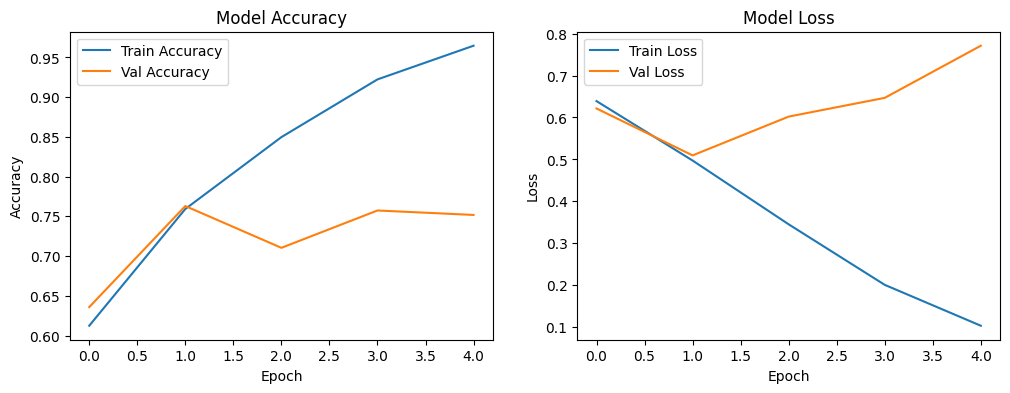


Sample Predictions on Test Data:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Sample 1: Negative (Confidence: 98.50%)
Sample 2: Positive (Confidence: 99.02%)
Sample 3: Negative (Confidence: 57.62%)
Sample 4: Positive (Confidence: 87.89%)
Sample 5: Positive (Confidence: 93.54%)


In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ============= 1. DEFINE HYPERPARAMETERS =============
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 32
EPOCHS = 5

# ============= 2. CUSTOM RNN CELL =============
class SimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(SimpleRNNCell, self).__init__(**kwargs)
        self.units = units 
        self.state_size = units 

    def build(self, input_shape):
        # input_shape will be (batch, features) for a single timestep
        input_dim = input_shape[-1]
        
        self.W_x = self.add_weight(
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            name='W_x'
        )
        self.W_h = self.add_weight(
            shape=(self.units, self.units),
            initializer='orthogonal',
            name='W_h'
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            name='bias'
        )
        self.built = True

    def call(self, inputs, states):
        prev_h = states[0]
        # h = tanh( x*Wx + h_prev*Wh + b )
        h = tf.tanh(tf.matmul(inputs, self.W_x) + tf.matmul(prev_h, self.W_h) + self.b)
        return h, [h]
    
    def get_initial_state(self, inputs=None, batch_size=None, dtype=None):
        # Handle dynamic batch sizes using tf.shape
        if batch_size is None and inputs is not None:
            batch_size = tf.shape(inputs)[0]
        
        # Default to float32 if not specified
        if dtype is None:
            dtype = tf.float32
            
        return [tf.zeros((batch_size, self.units), dtype=dtype)]

    def get_config(self):
        config = super(SimpleRNNCell, self).get_config()
        config.update({"units": self.units})
        return config

# ============= 3. MODEL BUILDER =============
def build_custom_rnn(vocab_size, embedding_dim, rnn_units, max_length):
    inputs = tf.keras.Input(shape=(max_length,))
    
    # Embedding: (batch, time) -> (batch, time, embed_dim)
    x = tf.keras.layers.Embedding(vocab_size, embedding_dim)(inputs)
    
    # RNN Layer uses our custom cell
    rnn_cell = SimpleRNNCell(rnn_units)
    rnn_layer = tf.keras.layers.RNN(rnn_cell, return_sequences=False)
    x = rnn_layer(x) 
    
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model 

# ============= 4. DATA LOADING =============
print("Loading IMDB dataset...")
# Note: Should numpy errors occur, allow_pickle is handled internally by recent TF versions
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

# Pad sequences
x_train = tf.keras.utils.pad_sequences(x_train, maxlen=MAX_LEN)
x_test = tf.keras.utils.pad_sequences(x_test, maxlen=MAX_LEN)

print(f"Training samples: {len(x_train)}, Test samples: {len(x_test)}")

# ============= 5. COMPILE & TRAIN =============
model = build_custom_rnn(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    rnn_units=RNN_UNITS,
    max_length=MAX_LEN
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\nStarting training...")
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1
)

# ============= 6. EVALUATION & VISUALIZATION =============
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# Plotting results
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ============= 7. PREDICTIONS =============
print("\nSample Predictions on Test Data:")
sample_texts = x_test[0:5]
predictions = model.predict(sample_texts)

for i, pred in enumerate(predictions):
    score = pred[0]
    sentiment = 'Positive' if score > 0.5 else 'Negative'
    confidence = score if score > 0.5 else 1 - score
    print(f"Sample {i+1}: {sentiment} (Confidence: {confidence:.2%})")

### Implementing Text Generation using RNN

In [35]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np 

text = 'hello world this is a simple rnn example for text generation'
chars = sorted(set(text))
char_to_idx = {c:  i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# Prepare Sequences 
seq_length = 10 
sequences = []
next_chars = []

for i in range(len(text) - seq_length):
    sequences.append([char_to_idx[c] for c in text[i:i+ seq_length]])
    next_chars.append(char_to_idx[text[i+ seq_length]])

X = np.array(sequences)
y = np.array(next_chars)

model = tf.keras.Sequential([
    keras.layers.Embedding(len(chars), 32, input_length=seq_length),
    keras.layers.LSTM(128, return_sequences = True),
    keras.layers.LSTM(128),
    keras.layers.Dense(len(chars), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit(X, y, batch_size=32, epochs=50, verbose=0)

def generate_text(model, start_string, length=100):
    input_seq = [char_to_idx[c] for c in start_string[-seq_length:]]
    generated = start_string 

    for _ in range(length):
        pred = model.predict(np.array([input_seq]), verbose=0)
        next_idx = np.argmax(pred[0])
        generated += idx_to_char[next_idx]
        input_seq = input_seq[1:] + [next_idx]

    return generated

print(generate_text(model, 'hello worl', 50))

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


hello worlttthiiihetei s   gaelpe footrxxttetheee xxxaaaoooo


### Implementd GAN

In [39]:
import tensorflow as tf 
from tensorflow import keras 
import numpy as np 

LATENT_DIM = 100 
BATCH_SIZE = 128 
EPOCHS = 50 

def build_generator():
    model = keras.Sequential([
        keras.layers.Dense(256, input_dim=LATENT_DIM),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(512),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(1024),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(784, activation='tanh')
    ])

    return model 

def build_discriminator():
    model = tf.keras.Sequential([
        keras.layers.Dense(512, input_dim=784),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),
       
        keras.layers.Dense(256),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(1, activation='sigmoid')
    ])

    return model 

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = keras.optimizers.Adam(0.0002, beta_1=0.5)
disc_optimizer = keras.optimizers.Adam(0.0002, beta_1=0.5)

bce = keras.losses.BinaryCrossentropy()

@tf.function 
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True) 
        fake_output = discriminator(fake_images,training=True)

        real_loss = bce(tf.ones_like(real_output), real_output)
        fake_loss = bce(tf.zeros_like(fake_output), fake_output)

        disc_loss = real_loss + fake_loss 

    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape: 
        fake_images = generator(noise, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = bce(tf.ones_like(fake_output), fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))

    return disc_loss, gen_loss 

def train(dataset, epochs):
    for epoch in range(epochs):
        for batch in dataset:
            disc_loss, gen_loss = train_step(batch)

        if epoch % 10 == 0:
            print(f'Epoch {epoch}: D_loss={disc_loss:.4f}, G_loss={gen_loss:.4f}')

    
(x_train, _), _ = keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]
x_train = x_train.reshape(-1, 784)
dataset = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)

# Train
train(dataset, EPOCHS)

Epoch 0: D_loss=1.1648, G_loss=0.9868


KeyboardInterrupt: 

In [40]:
# Generate random noise
noise = tf.random.normal([1, LATENT_DIM])

# Generate fake image from the trained generator
generated_image = generator(noise, training=False)

# generated_image is a tensor of shape (1, 784), reshape to 28x28 for visualization
generated_image = generated_image.numpy().reshape(28, 28)

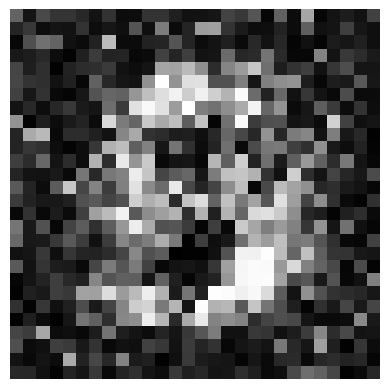

In [41]:
import matplotlib.pyplot as plt

plt.imshow(generated_image, cmap='gray')
plt.axis('off')
plt.show()

### Text Generation using RNN

In [45]:
import tensorflow as tf 
from tensorflow import keras 
import numpy as np 

text = "hello world this is a simple example for rnn text generation"
chars = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}
print(char_to_idx)
print(idx_to_char)
seq_length = 10
sequences = []
next_chars= []

for i in range(len(text) - seq_length):
    sequences.append([char_to_idx[c] for c in text[i: i+seq_length]])
    next_chars.append(char_to_idx[text[i+seq_length]])

X = np.array(sequences)
y = np.array(next_chars)

model = keras.Sequential([
    keras.layers.Embedding(len(chars), 32, input_length=seq_length),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(len(chars), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit(X, y, batch_size=32, epochs=50, verbose=0)

def generate_text(model, start_string, length=100):
    input_seq = [char_to_idx[c] for c in start_string[-seq_length]]
    generated = start_string 

    for _ in range(length):
        pred = model.predict(np.array([input_seq]), verbose=0)
        next_idx = np.argmax(pred[0])
        generated += idx_to_char[next_idx]
        input_seq = input_seq[1:] + [next_idx]

    return generated

print(generate_text(model, 'hello worl', 50))

{' ': 0, 'a': 1, 'd': 2, 'e': 3, 'f': 4, 'g': 5, 'h': 6, 'i': 7, 'l': 8, 'm': 9, 'n': 10, 'o': 11, 'p': 12, 'r': 13, 's': 14, 't': 15, 'w': 16, 'x': 17}
{0: ' ', 1: 'a', 2: 'd', 3: 'e', 4: 'f', 5: 'g', 6: 'h', 7: 'i', 8: 'l', 9: 'm', 10: 'n', 11: 'o', 12: 'p', 13: 'r', 14: 's', 15: 't', 16: 'w', 17: 'x'}


/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


hello worln                                                 


In [49]:
import tensorflow as tf 
from tensorflow import keras 
import numpy as np   

LATENT_DIM = 100
BATCH_SIZE = 128 
EPOCHS = 10 

def build_generator():
    model = keras.Sequential([
        keras.layers.Dense(256, input_dim=LATENT_DIM),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(512),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(1024),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(784, activation='tanh')
    ])

    return model 

def build_discriminator():
    model = keras.Sequential([
        keras.layers.Dense(512, input_dim=784),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    return model


generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = keras.optimizers.Adam(0.0002, beta_1=0.5)
disc_optimizer = keras.optimizers.Adam(0.0002, beta_1=0.5)

bce = keras.losses.BinaryCrossentropy()

@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images)
        
        real_loss = bce(tf.ones_like(real_output), real_output)
        fake_loss = bce(tf.zeros_like(fake_output), fake_output)

        disc_loss = real_loss + fake_loss 

    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape as gen_tape:
        fake_images = generator(noise, trainable=True)
        fake_output = discriminator(fake_images)
        gen_loss = bce(tf.ones_like(fake_output), fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gen_gradients, discriminator.trainable_variables))

    return disc_loss, gen_loss 

def train(dataset, epochs):
    for epoch in range(epochs):
        for batch in dataset:
            disc_loss, gen_loss = train_step(batch)

            if epoch % 5 ==0:
                print(f'Epoch {epoch}: D_loss={disc_loss:.4f}, G_loss={gen_loss:.4f}')


(x_train, _), _ = keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)

dataset =tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)

train(dataset, EPOCHS)


/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TypeError: in user code:

    File "/var/folders/52/cdp4_l0n12d9kcjj_bqgm1x00000gn/T/ipykernel_97105/2481210846.py", line 50, in train_step  *
        with tf.GradientTape as disc_tape:

    TypeError: 'type' object does not support the context manager protocol


In [52]:
import tensorflow as tf
import numpy as np 
from tensorflow import keras 

text = 'hello world this is sample code to implement rnn used for text generation'
chars= sorted(set(text))
char2idx={c:i for i, c in enumerate(chars)}
idx2char ={i:c for i , c in enumerate(chars)}


seq_length = 10 
sequences=[]
next_chars = []

for i in range(len(text) - seq_length):
    sequences.append([char2idx[c] for c in text[i: i+seq_length]])
    next_chars.append(char2idx[text[i+seq_length]])

X, y = np.array(sequences), np.array(next_chars)

model = keras.Sequential([
    keras.layers.Embedding(len(chars), 32, input_length=seq_length),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(len(chars), activation='softmax'),
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit(X, y, batch_size=32, epochs=10, verbose=0)

def generate_text(model, start_string, length=100):
    input_seq= [char2idx[c] for c in start_string[-seq_length:]]
    generated = start_string

    for _ in range(length):
        pred = model.predict(np.array([input_seq]))

        next_idx = np.argmax(pred[0])
        generated += idx2char[next_idx]

        input_seq = input_seq[1:] + [next_idx]

    return generated 

print(generate_text(model, 'hello world', 50))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

In [ ]:
import tensorflow as tf
import numpy as np 
from tensorflow import keras 


latent_dim = 100
batch_size=128
epochs = 10 

def build_generator():
    model = keras.Sequential([
        keras.layers.Dense(256, input_dim=LATENT_DIM),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(512),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(1024),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(784, activation='tanh') 
    ])
    return model

def build_discriminator():
    model = keras.Sequential([
        keras.layers.Dense(512, input_dim=784),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model 

generator = build_generator()
discriminator = build_discriminator()

gen_optim = keras.optimizers.Adam(0.0002, beta_1=0.5)
disc_optim = keras.optimizers.Adam(0.0002, beta_1=0.5)

bce = keras.losses.BinaryCrossentropy()


@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape as disc_tape:
        fake_images = generator(noise, training=True)
        
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        real_loss = bce(tf.ones_like(real_output), real_output)
        fake_loss = bce(tf.zeros_like(fake_output), fake_output)

        disc_loss = real_loss + fake_loss 

    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    disc_optimizer


